In [2]:
import numpy as np

def read_poscar(filename="relaxed-POSCAR"):
    with open(filename, "r") as f:
        lines = f.readlines()

    scale = float(lines[1].strip())
    a_vec = [float(x) for x in lines[2].split()]
    b_vec = [float(x) for x in lines[3].split()]
    c_vec = [float(x) for x in lines[4].split()]
    species_line = lines[5].strip()
    counts_line  = lines[6].strip()
    coord_type   = lines[7].strip()
    atom_coords  = [lines[i].strip() for i in range(8, len(lines)) if lines[i].strip()]

    return scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords

strain_list = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16, 18]

scale, a_vec, b_vec, c_vec, species_line, counts_line, coord_type, atom_coords = read_poscar()

for i in strain_list:
    factor = 1 + i / 100

    # Only scale the in-plane (x, y) components; leave z untouched
    def strain_vec(v):
        return [v[0] * factor , v[1] * factor, v[2]]

    a_s = strain_vec(a_vec)
    b_s = strain_vec(b_vec)
    c_s = strain_vec(c_vec)

    filename = f"POSCAR-{i}"
    content = (
        f"Buckled BiAs strained {i}%\n"
        f"   {scale:.14f}\n"
        f"\t{a_s[0]:.15f}\t{a_s[1]:.15f}\t{a_s[2]:.15f}\n"
        f"\t{b_s[0]:.15f}\t{b_s[1]:.15f}\t{b_s[2]:.15f}\n"
        f"\t{c_s[0]:.15f}\t{c_s[1]:.15f}\t{c_s[2]:.15f}\n"
        f"   {species_line}\n"
        f"    {counts_line}\n"
        f"{coord_type}\n"
    )
    for coord in atom_coords:
        content += f"\t{coord}\n"

    with open(filename, "w") as f:
        f.write(content)

    print(f"Written: {filename}")

Written: POSCAR-2
Written: POSCAR-4
Written: POSCAR-6
Written: POSCAR-8
Written: POSCAR-10
Written: POSCAR-11
Written: POSCAR-12
Written: POSCAR-13
Written: POSCAR-14
Written: POSCAR-16
Written: POSCAR-18


[0.0, 0.963, 1.797, 2.278, 3.241]
[0.0, 0.944, 1.762, 2.234, 3.179]
[0.0, 0.927, 1.729, 2.192, 3.119]
[0.0, 0.909, 1.697, 2.152, 3.061]
[0.0, 0.893, 1.666, 2.113, 3.005]
[0.0, 0.885, 1.651, 2.094, 2.978]
[0.0, 0.877, 1.636, 2.075, 2.952]
[0.0, 0.869, 1.622, 2.056, 2.926]
[0.0, 0.862, 1.608, 2.038, 2.9]
[0.0, 0.847, 1.58, 2.003, 2.85]


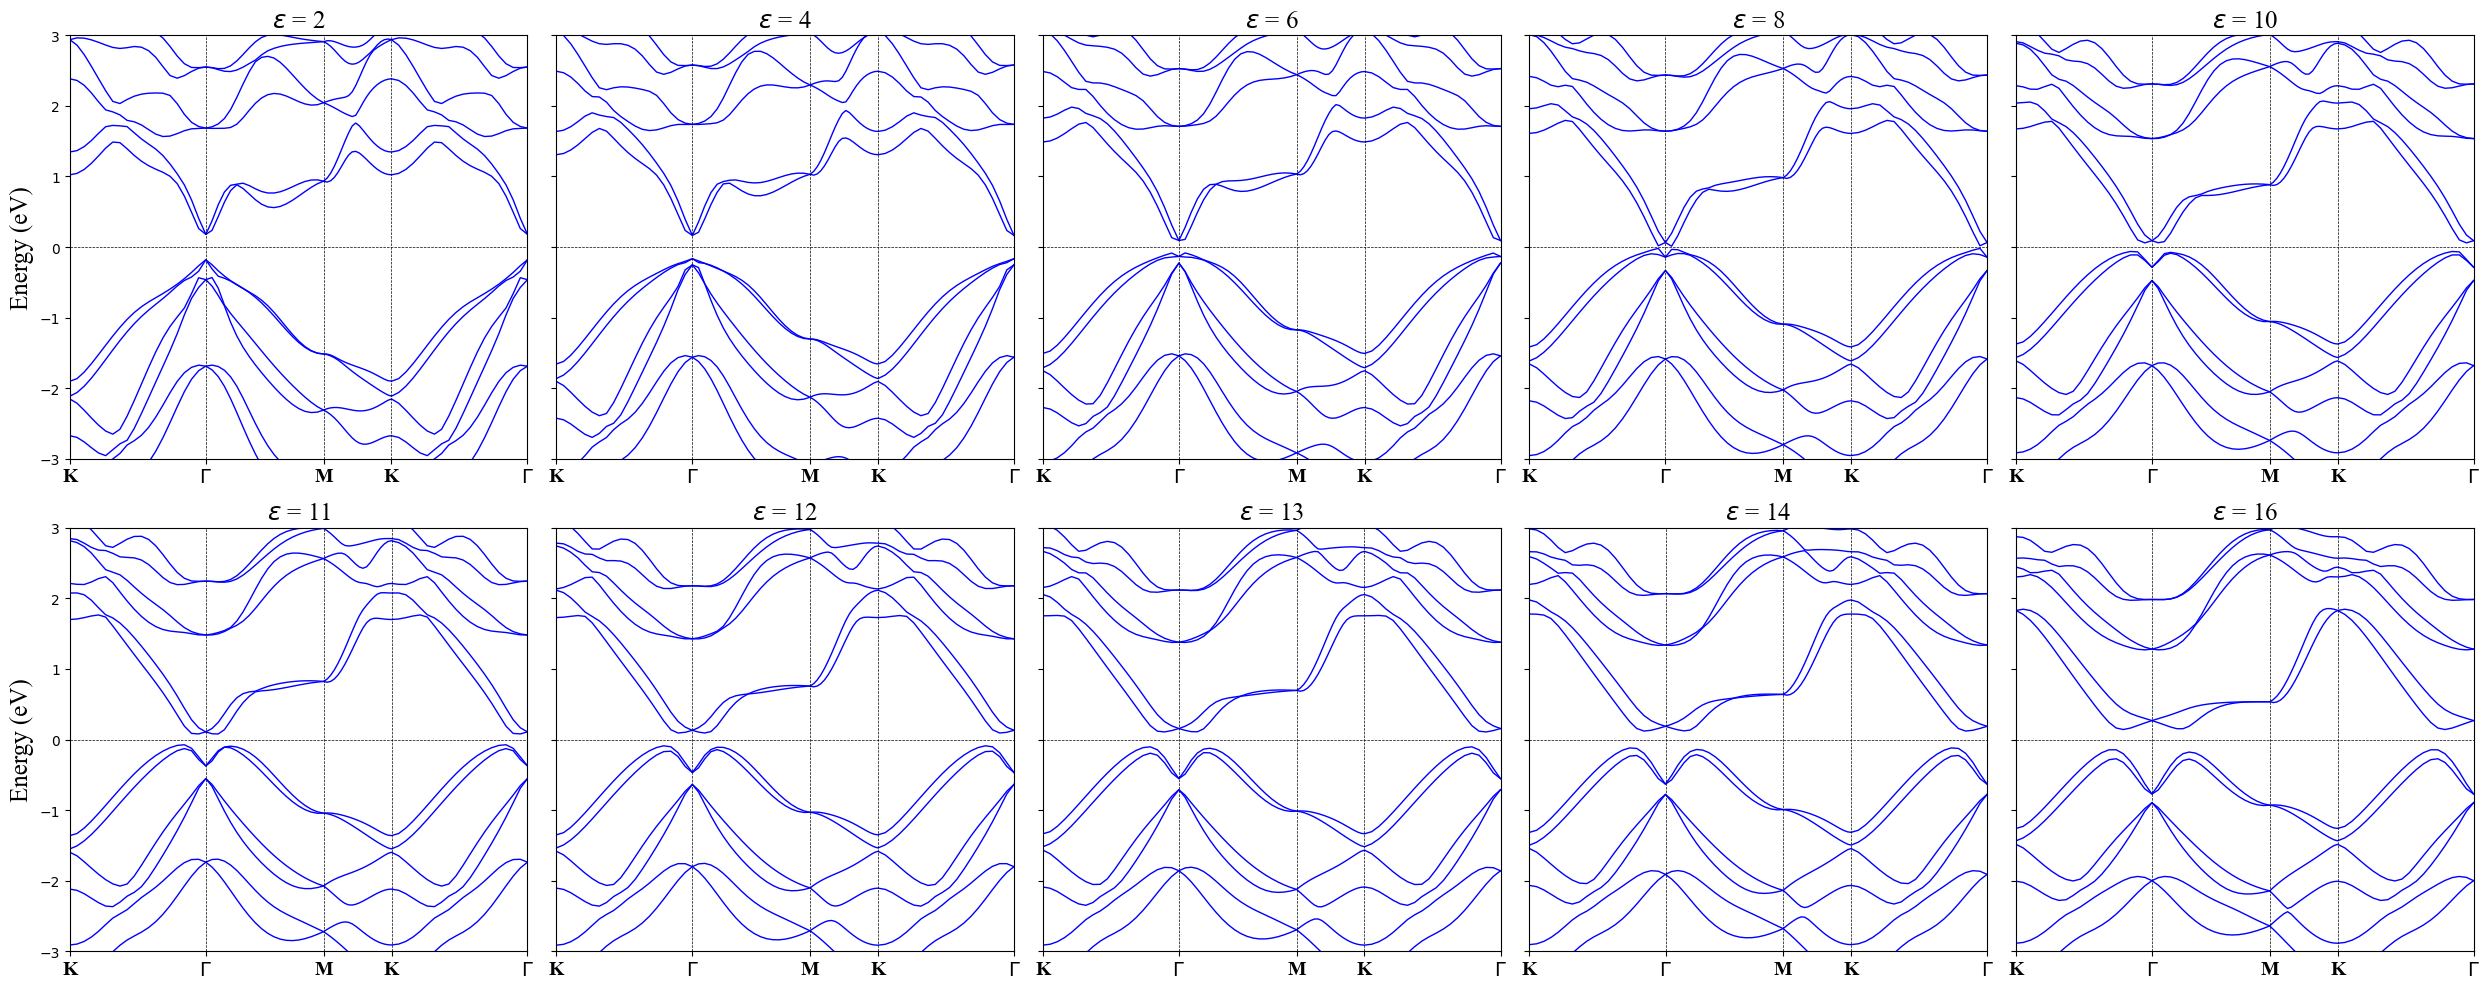

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Config ---
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]
high_symmetry_points = [0, 0.780, 1.456, 1.846, 2.626]
high_sym_labels = ['K', r'$\Gamma$', 'M', 'K', r'$\Gamma$']

# --- Load all datasets ---
datasets = {i: np.loadtxt(f"{i}-REFORMATTED_BAND.dat") for i in file_indices}

# --- Layout: 4 cols, enough rows to fit all ---
n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows),
                          sharey=True)
axes = axes.flatten()

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

for ax, (idx, data) in zip(axes, datasets.items()):
    k = data[:, 0]
    bands = data[:, 1:]
    high_sym_points = read_klabels(f"labels/{idx}-KLABELS")
    print(high_sym_points)
    for i in range(bands.shape[1]):
        ax.plot(k, bands[:, i], color='blue', linewidth=1, label='DFT' if i == 0 else "")

    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlim(k.min(), k.max())

    for i in range(len(high_sym_points)):
        ax.axvline(high_sym_points[i],lw=0.5,ls="--",color='black')

    ax.set_ylim(-3, 3)
    ax.set_xticks(high_sym_points)
    ax.set_xticklabels(high_sym_labels, fontsize=14, fontname="Times New Roman",fontweight="bold")
    ax.set_title(rf'$\epsilon$ = {idx}',fontsize=18, fontname="Times New Roman")

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('Energy (eV)', fontsize=18, fontname="Times New Roman")

# Hide any unused subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("biaxial-bands.png",bbox_inches='tight' ,dpi=300)
plt.show()

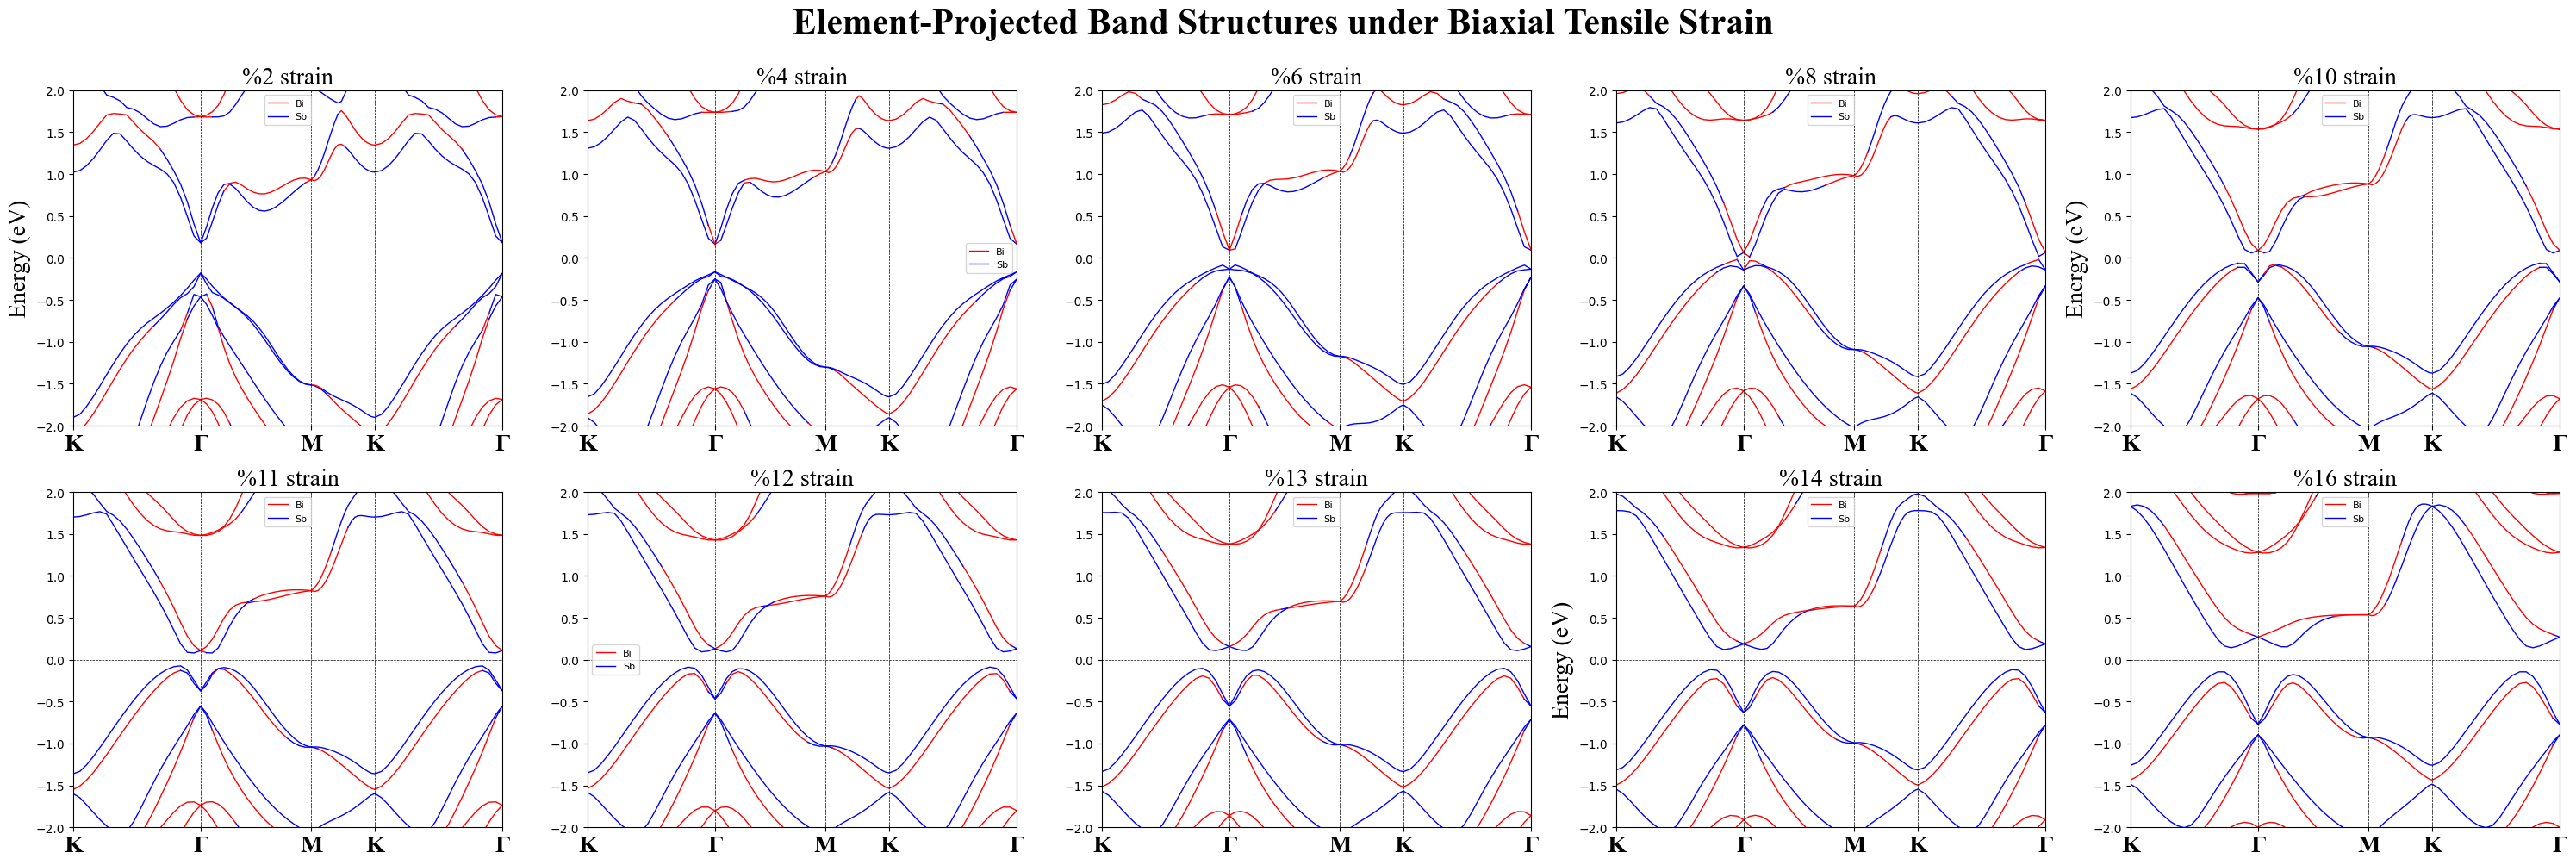

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load all datasets
data_2 = np.loadtxt("2-PBAND_ELEMENTS_SOC.dat")
data_4 = np.loadtxt("4-PBAND_ELEMENTS_SOC.dat")
data_6 = np.loadtxt("6-PBAND_ELEMENTS_SOC.dat")
data_8 = np.loadtxt("8-PBAND_ELEMENTS_SOC.dat")
data_10 = np.loadtxt("10-PBAND_ELEMENTS_SOC.dat")
data_11 = np.loadtxt("11-PBAND_ELEMENTS_SOC.dat")
data_12 = np.loadtxt("12-PBAND_ELEMENTS_SOC.dat")
data_13 = np.loadtxt("13-PBAND_ELEMENTS_SOC.dat")
data_14 = np.loadtxt("14-PBAND_ELEMENTS_SOC.dat")
data_16 = np.loadtxt("16-PBAND_ELEMENTS_SOC.dat")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_11, data_12, data_13, data_14, data_16]

def read_klabels(filename):
    """
    Parse a KLABELS file and return the list of k-path positions.
    Skips the header line and any empty lines.
    """
    points = []
    with open(filename, 'r') as f:
        lines = f.readlines()
    # Skip header (first line), read lines with two columns
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                points.append(float(parts[1]))
            except ValueError:
                continue
    return points

# Collect all datasets and their corresponding KLABELS files
labels = ['2', '4', '6', '8','10', '11' ,'12', '13' ,'14', '16']

datasets = []
klabels_list = []
for label in labels:
    datasets.append(np.loadtxt(f"{label}-PBAND_ELEMENTS_SOC.dat"))
    klabels_list.append(read_klabels(f"labels/{label}-KLABELS"))

# Define elements and their corresponding columns
element_names = ['Bi', 'Sb']
element_columns = [2, 3]
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

high_sym_labels = ['K', 'Γ', 'M', 'K' ,'Γ']

# Create figure with subplots
fig, axes = plt.subplots(2,5, figsize=(30, 10))
axes = axes.flatten()

for idx, (elemented_data, label, sym_points) in enumerate(zip(datasets, labels, klabels_list)):
    ax = axes[idx]

    # Find dominant element at each k-point
    dominant_elements = np.argmax(elemented_data[:, element_columns], axis=1)

    color_changes = np.diff(dominant_elements)
    change_indices = np.where(color_changes != 0)[0] + 1
    segment_indices = np.concatenate(([0], change_indices, [len(elemented_data)]))

    labeled_elements = set()

    for i in range(len(segment_indices) - 1):
        start = segment_indices[i]
        end = segment_indices[i + 1]

        dominant_idx = dominant_elements[start]
        color = colors[dominant_idx]
        elem_label = element_names[dominant_idx]

        if elem_label not in labeled_elements:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1],
                    color=color, label=elem_label, linewidth=1)
            labeled_elements.add(elem_label)
        else:
            ax.plot(elemented_data[start:end+1, 0], elemented_data[start:end+1, 1],
                    color=color, linewidth=1)

    for point in sym_points:
        ax.axvline(point,lw=0.5,color='black',ls='--')

    ax.axhline(0,lw=0.5,color='black',ls='--')

    ax.set_xticks(sym_points)
    ax.set_xticklabels(high_sym_labels,fontname="Times New Roman",fontweight="bold",fontsize=20)
    ax.set_xlim(min(elemented_data[:, 0]), max(elemented_data[:, 0]))
    ax.set_ylim(-2, 2)
    ax.set_title(f'%{label} strain',fontsize=20,fontname="Times New Roman")
    if idx == 0 or idx == 4 or idx ==8:
        ax.set_ylabel('Energy (eV)',fontsize=20,fontname="Times New Roman")
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.suptitle("Element-Projected Band Structures under Biaxial Tensile Strain ",
            fontsize=30,fontname="Times New Roman", fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

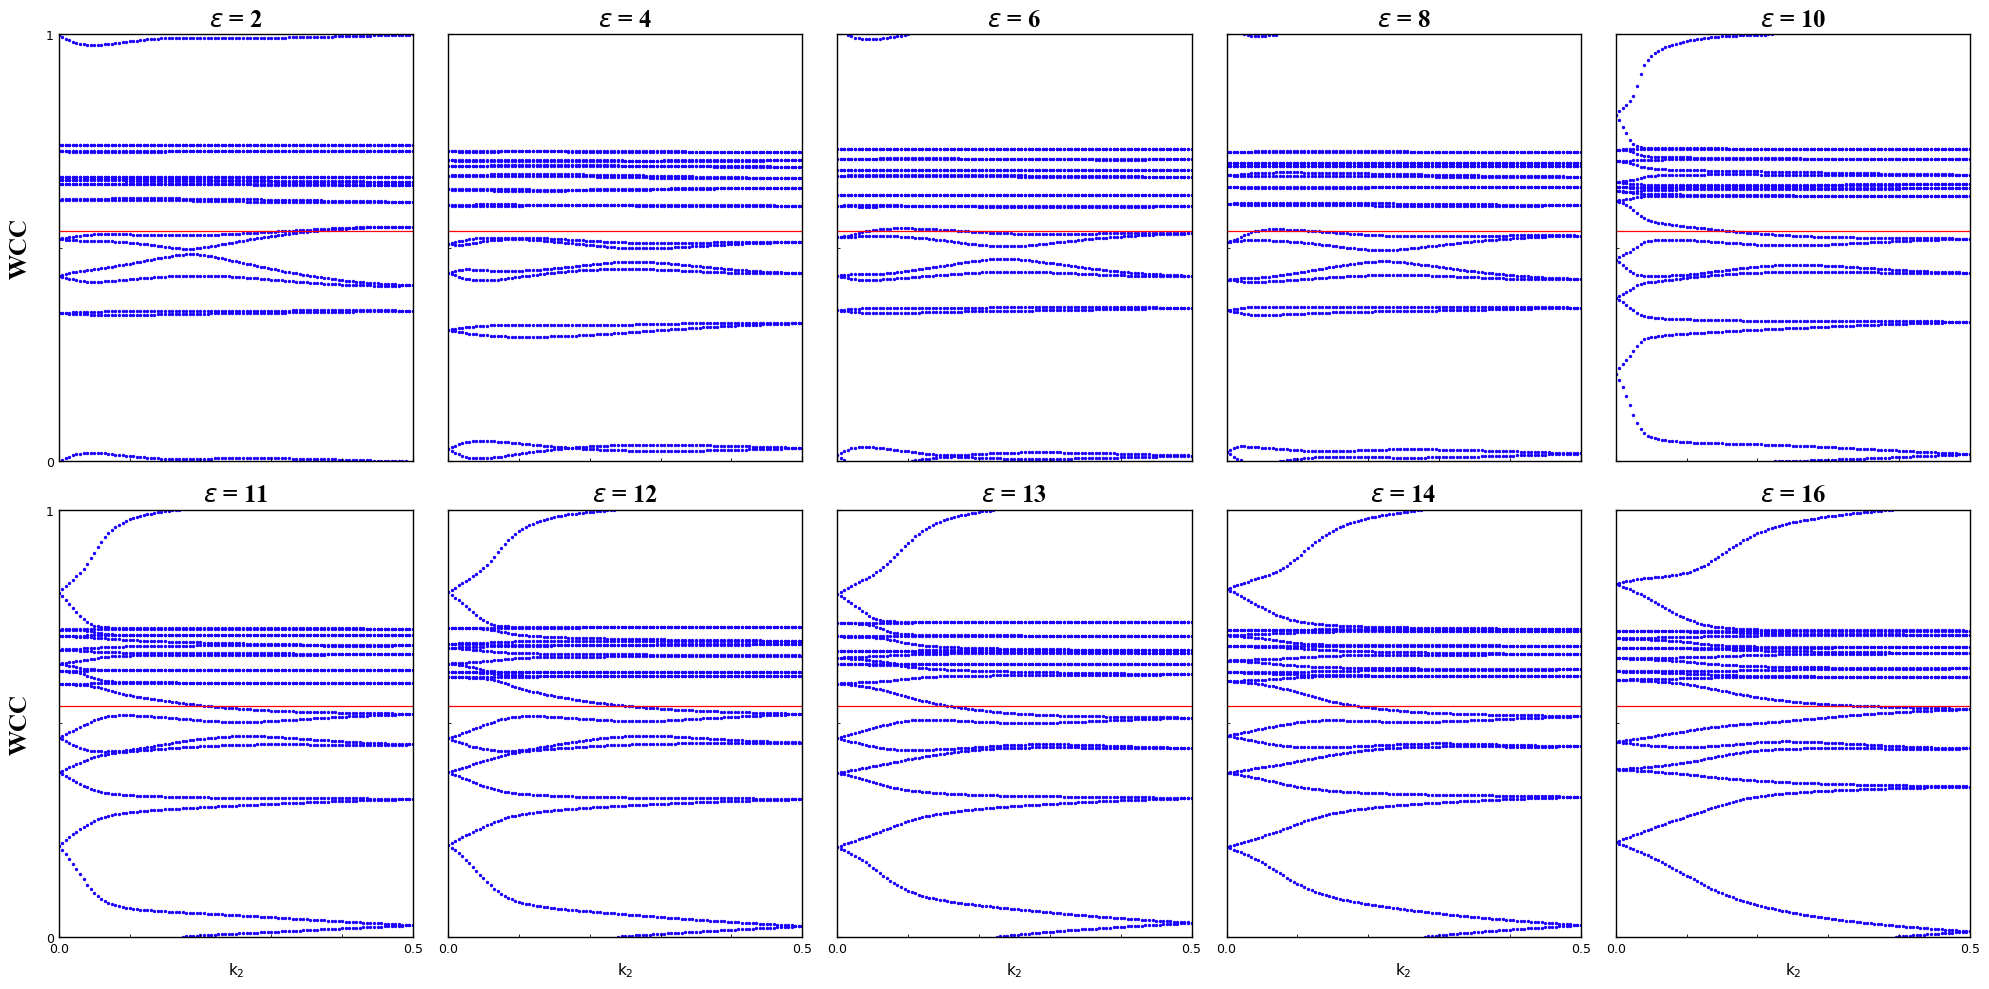

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Config ---
LCOLOR = "#1900FF"
file_indices = [2, 4, 6, 8, 10, 11, 12, 13, 14, 16]

n_plots = len(file_indices)
n_cols = 5
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, idx in zip(axes, file_indices):
    try:
        data = np.loadtxt(f"{idx}-wanniercenter3D_Z2_6.dat")
        ax.scatter(data[:, 0] / 2, data[:, 1],
                   s=2, color=LCOLOR, marker='o', linewidths=1)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'e{idx} not found',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)

    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.tick_params(axis='x', which='both', direction='in', labelsize=9)
    ax.axhline(0.54,lw = 0.9, color='red', ls = '-')
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.0f'))
    ax.tick_params(axis='y', which='both', direction='in', labelsize=9)

    ax.set_title(rf'$\epsilon$ = {idx}', fontname="Times New Roman",fontweight="bold",fontsize=18)

    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel('WCC', rotation=90, fontname="Times New Roman",fontweight="bold", fontsize=18, labelpad=10)
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel(r'k$_2$', fontsize=11)

    for spine in ax.spines.values():
        spine.set_linewidth(1)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("wannier_centers_comparison_biaxial.png", dpi=300)
plt.show()

Global DOS range: [1.7072062, 7.3993234]


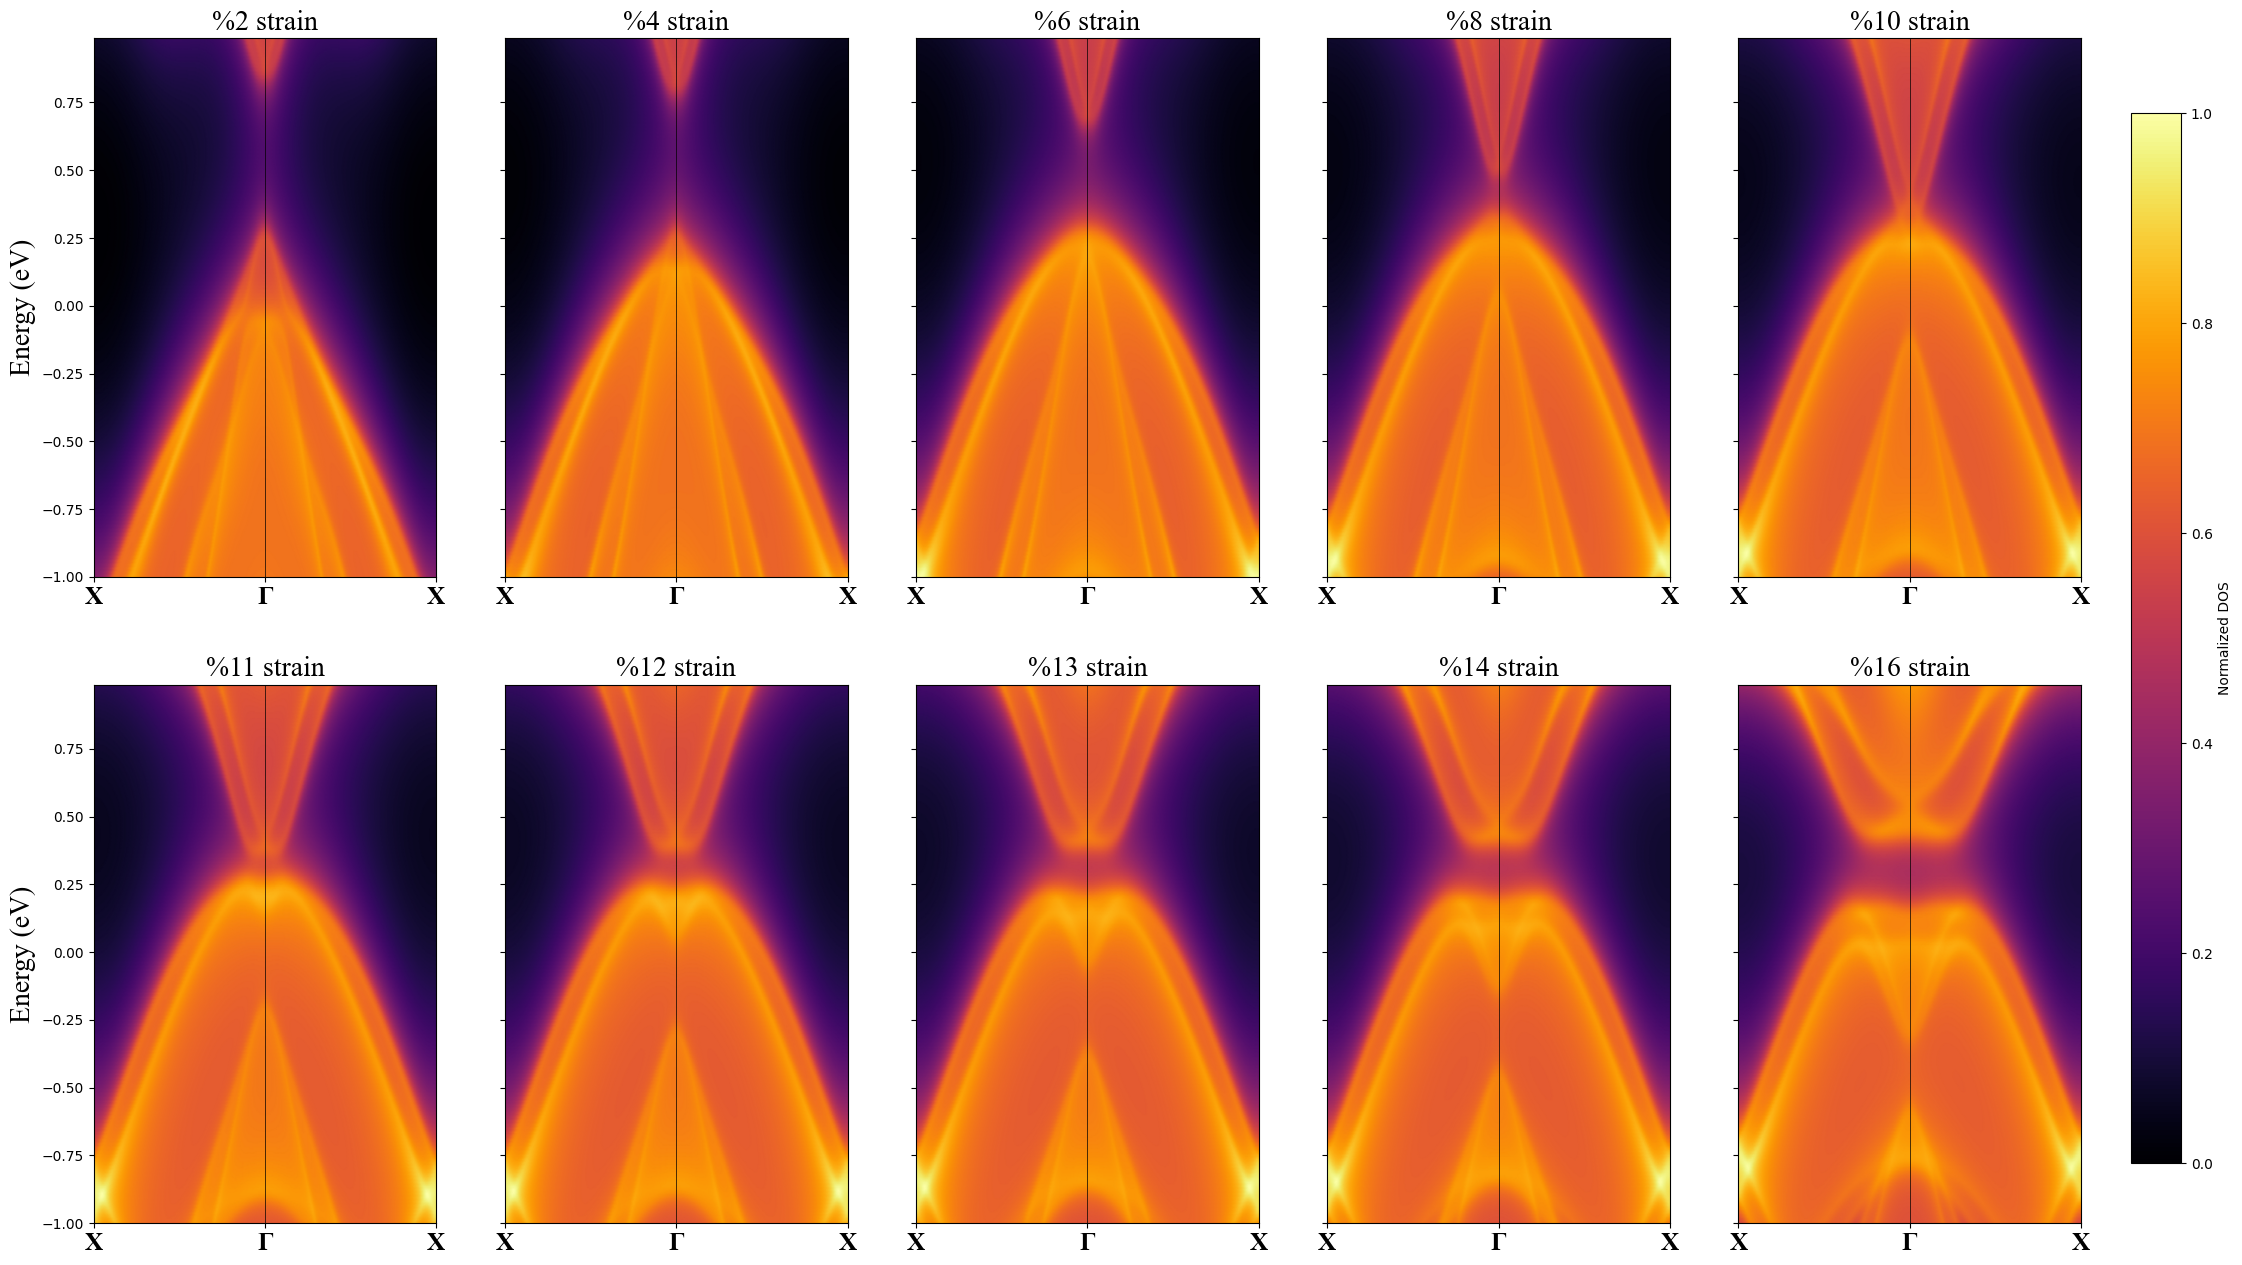

Plot displayed!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata

# Loading all data
data_2 = np.loadtxt("2-dos.dat_bulk")
data_4 = np.loadtxt("4-dos.dat_bulk")
data_6 = np.loadtxt("6-dos.dat_bulk")
data_8 = np.loadtxt("8-dos.dat_bulk")
data_10 = np.loadtxt("10-dos.dat_bulk")
data_11 = np.loadtxt("11-dos.dat_bulk")
data_12 = np.loadtxt("12-dos.dat_bulk")
data_13 = np.loadtxt("13-dos.dat_bulk")
data_14 = np.loadtxt("14-dos.dat_bulk")
data_16 = np.loadtxt("16-dos.dat_bulk")

# Collect all datasets
datasets = [data_2, data_4, data_6, data_8, data_10, data_11, data_12, data_13, data_14, data_16]
labels = ['2', '4', '6', '8', '10', '11', '12', '13', '14', '16']

# Find global min and max of DOS values across all datasets
global_min = min(data[:, 2].min() for data in datasets)
global_max = max(data[:, 2].max() for data in datasets)

print(f"Global DOS range: [{global_min}, {global_max}]")

# Normalize all datasets to [0, 1] range
normalized_datasets = []
for data in datasets:
    data_normalized = data.copy()
    # Min-max normalization
    data_normalized[:, 2] = (data[:, 2] - global_min) / (global_max - global_min)
    normalized_datasets.append(data_normalized)

from matplotlib.colors import LinearSegmentedColormap

# Define custom black-white-yellow colormap
colors = ['#000000', '#FFFFFF', "#FFAE00"]
n_bins = 256  # Discretizes the interpolation into bins
cmap_custom = LinearSegmentedColormap.from_list('black_white_yellow', colors, N=n_bins)

# Function to plot a single dataset
def plot_dos(data, title_suffix, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    x = data[:, 0]
    y = data[:, 1]
    z = data[:, 2]  # Already normalized, no exponential needed
    
    # Create interpolated grid for smooth plotting
    xi = np.linspace(x.min(), x.max(), 400)
    yi = np.linspace(y.min(), y.max(), 400)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method='cubic')
    
    # Plot the data
    im = ax.pcolormesh(Xi, Yi, Zi, cmap="inferno", shading='gouraud', 
                       vmin=0, vmax=1)  # Fixed scale [0, 1]
    
    # Set axis limits
    ax.set_xlim(min(x), max(x))
    
    # Set x-axis ticks and labels
    ax.set_xticks([min(x), (min(x)+max(x))/2, max(x)])
    ax.set_xticklabels(['X', 'Γ', 'X'],fontname="Times New Roman", fontweight="bold",fontsize=18)
    
    
    # Add vertical line at Gamma point
    ax.axvline(x=(min(x)+max(x))/2, color='black', linewidth=0.5)

    ax.set_title(f"%{title_suffix} strain",fontname="Times New Roman", fontsize=20)

    return im

# Create a comparison plot with all datasets
fig, axes = plt.subplots(2, 5, figsize=(25, 15),sharey=True)
axes = axes.flatten()

for i, (data, label) in enumerate(zip(normalized_datasets, labels)):
    im = plot_dos(data, label, axes[i])
    if i == 0 or i == 5:
        axes[i].set_ylabel('Energy (eV)', fontname="Times New Roman", fontsize=20)
# Adjust subplot spacing to make room for colorbar on the right
fig.subplots_adjust(right=0.92, top=0.90)  # Added top spacing for title

# Add a shared colorbar on the far right
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Normalized DOS')
plt.savefig("surface_states_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot displayed!")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation


labels = ['2', '4', '6', '8', '10', '11', '12', '13', '14', '16']

import matplotlib
matplotlib.use("QtAgg")

def read_klabels(filename):
    """
    Parse a KLABELS file and return (label_names, positions).
    Skips the header line and any empty lines.
    """
    names, points = [], []
    with open(filename, 'r') as f:
        lines = f.readlines()
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                pos = float(parts[1])
            except ValueError:
                continue
            names.append(parts[0])
            points.append(pos)
    return names, points


def format_hsp_label(name):
    """Map common VASPKIT/WannierTools label spellings to LaTeX."""
    mapping = {
        'GAMMA': r'$\Gamma$',
        'G': r'$\Gamma$',
    }
    return mapping.get(name.upper(), name)


def local_norm(arr):
    span = arr.max() - arr.min()
    if span == 0:
        return np.zeros_like(arr)
    return (arr - arr.min()) / span



orbital_order = [0, 2, 3, 1]  
orbital_names = ['s', '$p_z$', '$p_x$', '$p_y$']

all_data = {}


high_sym_labels = ['K', 'Γ', 'M', 'K' ,'Γ']


for label in labels:
    data_bi = pd.read_csv(f"{label}-PBAND_Bi_SOC.dat", comment='#',
                           delim_whitespace=True, header=None, skiprows=2)
    data_sb = pd.read_csv(f"{label}-PBAND_Sb_SOC.dat", comment='#',
                           delim_whitespace=True, header=None, skiprows=2)

    k = data_bi[0].values.astype(float)
    e = data_bi[1].values.astype(float)

    bi_vals = [data_bi[i].values.astype(float) for i in range(2, 6)]  # s, px, py, pz
    sb_vals = [data_sb[i].values.astype(float) for i in range(2, 6)]

    bi_norms = [local_norm(v) for v in bi_vals]
    sb_norms = [local_norm(v) for v in sb_vals]

    orbitals = ([bi_norms[i] for i in orbital_order] +
                [sb_norms[i] for i in orbital_order])

    hsp_names_raw, hsp_points = read_klabels(f"labels/{label}-KLABELS")
    hsp_labels = ['K', 'Γ', 'M', 'K' ,'Γ']

    all_data[label] = dict(
        k=k, e=e, orbitals=orbitals,
        hsp_points=hsp_points, hsp_labels=hsp_labels
    )

names = ['Bi $s$', 'Bi $p_z$', 'Bi $p_x$', 'Bi $p_y$',
         'Sb $s$', 'Sb $p_z$', 'Sb $p_x$', 'Sb $p_y$']

cmap = 'magma'

fig, axes = plt.subplots(2, 4, figsize=(20, 17), sharex=False, sharey=True)
fig.subplots_adjust(right=0.88, top=0.90, bottom=0.15, hspace=0.2, wspace=0.05)
axes = axes.flatten()

init_label = labels[0]
d0 = all_data[init_label]

scatters = []
vlines = []

for idx, name in enumerate(names):
    ax = axes[idx]

    scatter = ax.scatter(
        d0['k'], d0['e'],
        c=d0['orbitals'][idx],
        s=15, cmap=cmap, alpha=0.8,
        vmin=0, vmax=1
    )
    scatters.append(scatter)

    ax.set_title(f'{name} orbital contribution', fontsize=18, fontweight='bold')
    ax.set_ylim(-3, 3)
    ax.set_xlim(min(d0['k']), max(d0['k']))

    frame_vlines = [ax.axvline(x=x, color='gray', linestyle='--', lw=0.5)
                     for x in d0['hsp_points']]
    vlines.append(frame_vlines)
    ax.axhline(0, ls='--', lw=0.5, color='black')

    ax.set_xticks(d0['hsp_points'])
    ax.set_xticklabels(d0['hsp_labels'], fontsize=18,
                        fontname="Times New Roman", fontweight="bold")

    if idx % 4 == 0:
        ax.set_ylabel(r'$Energy (eV)$', fontsize=18, fontname="Times New Roman")

suptitle = fig.suptitle(f'Strain = {init_label}%', fontsize=22, fontweight='bold')


cbar_ax = fig.add_axes([0.90, 0.20, 0.02, 0.62])
cbar = fig.colorbar(scatters[-1], cax=cbar_ax)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
cbar.set_label('Normalized orbital contribution', fontsize=20,
                fontname="Times New Roman", fontweight="bold")
cbar.ax.tick_params(labelsize=10)


def update(frame):
    label = labels[frame]
    d = all_data[label]

    for orb_idx, ax in enumerate(axes):

        scatters[orb_idx].set_offsets(
            np.column_stack([d['k'], d['e']])
        )

        scatters[orb_idx].set_array(
            d['orbitals'][orb_idx]
        )

        ax.set_xlim(d['k'].min(), d['k'].max())

        # remove old symmetry lines
        for ln in vlines[orb_idx]:
            ln.remove()

        # draw new symmetry lines
        vlines[orb_idx] = [
            ax.axvline(
                x=x,
                color='gray',
                linestyle='--',
                lw=0.5
            )
            for x in d['hsp_points']
        ]

        ax.set_xticks(d['hsp_points'])
        ax.set_xticklabels(
            d['hsp_labels'],
            fontsize=18,
            fontname="Times New Roman",
            fontweight="bold"
        )

    suptitle.set_text(f"Strain = {label}%")

    return scatters


ani = FuncAnimation(
    fig,
    update,
    frames=len(labels),
    interval=800,      # milliseconds per frame
    repeat=True,
    blit=False
)

ani.save(
    "OrbitalProjection.gif",
    writer="pillow",
    fps=2
)

C:\Users\furka\AppData\Local\Temp\ipykernel_25448\1909749331.py:63: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(f"{label}-PBAND_Bi_SOC.dat", comment='#',
C:\Users\furka\AppData\Local\Temp\ipykernel_25448\1909749331.py:65: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sb = pd.read_csv(f"{label}-PBAND_Sb_SOC.dat", comment='#',
C:\Users\furka\AppData\Local\Temp\ipykernel_25448\1909749331.py:63: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_bi = pd.read_csv(f"{label}-PBAND_Bi_SOC.dat", comment='#',
C:\Users\furka\AppData\Local\Temp\ipykernel_25448\1909749331.py:65: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a futu

In [1]:
import matplotlib.animation as animation
print(animation.writers.list())

['pillow', 'html']


C:\Users\furka\AppData\Local\Temp\ipykernel_9468\627518010.py:76: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data1 = pd.read_csv(f1, comment="#", delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_9468\627518010.py:77: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data2 = pd.read_csv(f2, comment="#", delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_9468\627518010.py:76: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data1 = pd.read_csv(f1, comment="#", delim_whitespace=True, header=None, skiprows=2)
C:\Users\furka\AppData\Local\Temp\ipykernel_9468\627518010.py:77: FutureWarning: The 'delim_whitespace' keyword in 

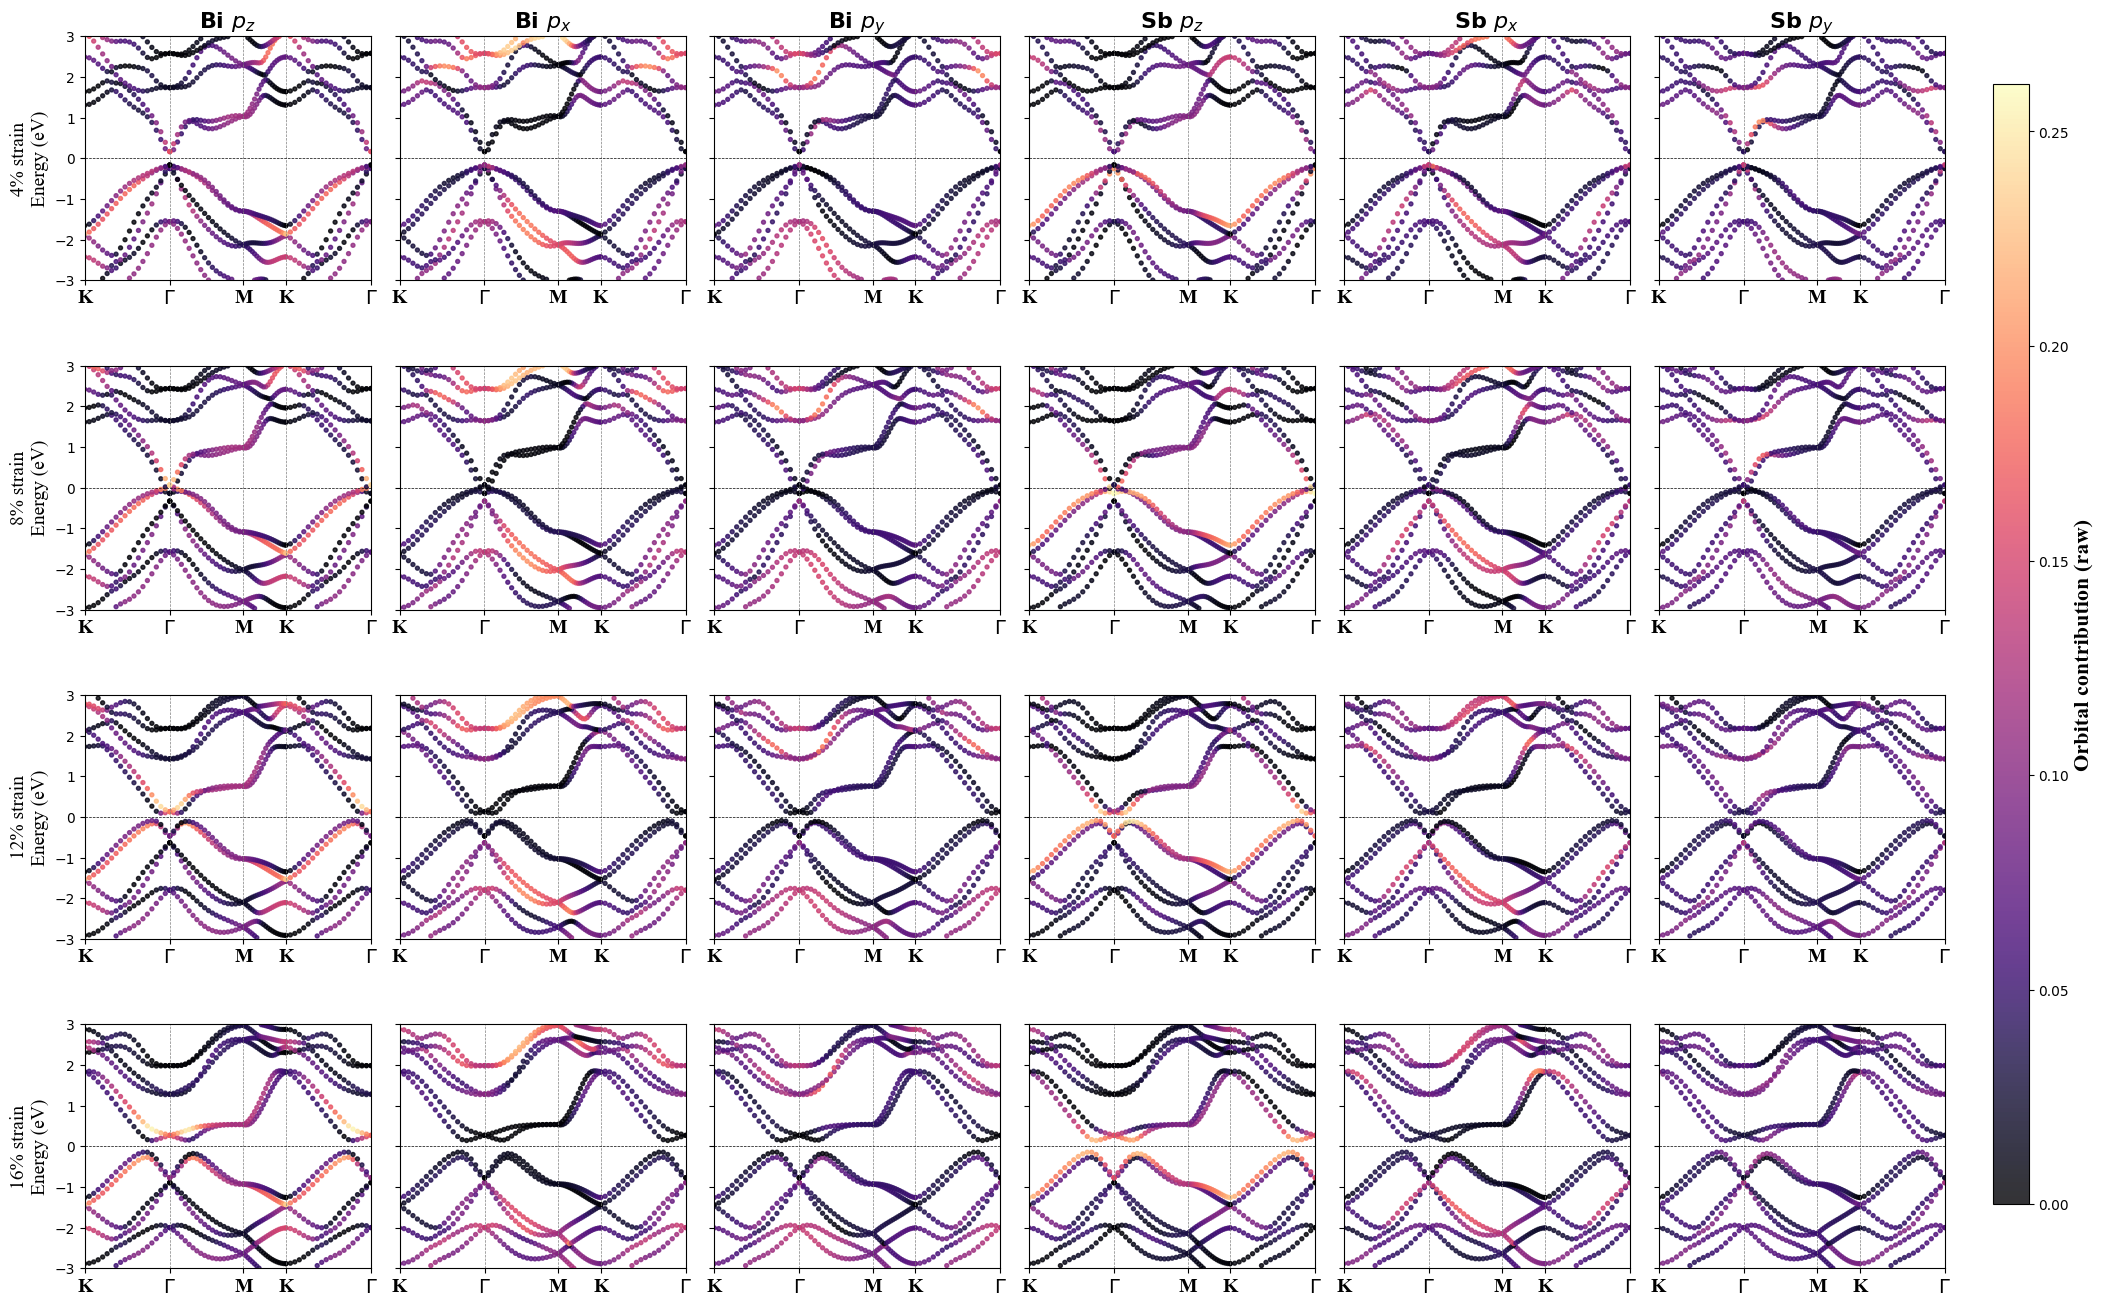

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------
# Config
# ---------------------------------------------------------------
STRAINS = [4, 8, 12, 16]          # strain values (%) -> one row each
ATOM1, ATOM2 = "Bi", "Sb"         # change ATOM2 to "Sb" for BiSb system
cmap = "magma"

# Column order (standard VASP PROCAR/PBAND): s, py, pz, px, d...
# -> data column indices for the three p orbitals:
P_COLUMNS = {"pz": 4, "px": 5, "py": 3}
ORBITAL_ORDER = ["pz", "px", "py"]  # column order within each atom block


def get_filepaths(strain):
    """Adjust this to match your actual directory / naming convention."""
    f1 = f"{strain}-PBAND_{ATOM1}_SOC.dat"
    f2 = f"{strain}-PBAND_{ATOM2}_SOC.dat"
    return f1, f2


def get_klabels_path(strain):
    return f"labels/{strain}-KLABELS"


def read_klabels(filename):
    """
    Parse a KLABELS file and return (label_names, positions).
    Skips the header line and any empty lines.
    """
    names, points = [], []
    with open(filename, 'r') as f:
        lines = f.readlines()
    for line in lines[1:]:
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) == 2:
            try:
                pos = float(parts[1])
            except ValueError:
                continue
            names.append(parts[0])
            points.append(pos)
    return names, points


def format_label(name):
    """Convert raw KLABELS names (e.g. GAMMA) into LaTeX-friendly labels."""
    special = {
        "GAMMA": r"$\Gamma$",
        "\\Gamma": r"$\Gamma$",
    }
    return special.get(name, name)


ENERGY_WINDOW = (-3, 3)  # only keep points with E in this range


def local_norm(arr):
    # No normalization -- keep raw values so color scale is comparable
    # across strains/orbitals instead of being stretched per-panel.
    return arr


def load_strain_data(strain):
    """Load k, E, and each of the 6 orbital contributions
    (Bi pz/px/py, As pz/px/py) for one strain value, masked to points
    whose energy falls within ENERGY_WINDOW."""
    f1, f2 = get_filepaths(strain)

    data1 = pd.read_csv(f1, comment="#", delim_whitespace=True, header=None, skiprows=2)
    data2 = pd.read_csv(f2, comment="#", delim_whitespace=True, header=None, skiprows=2)

    k = np.array(data1[0])
    e = np.array(data1[1])

    emin, emax = ENERGY_WINDOW
    mask = (e >= emin) & (e <= emax)
    k = k[mask]
    e = e[mask]

    orbitals = {}
    for orb in ORBITAL_ORDER:
        col = P_COLUMNS[orb]
        orbitals[f"{ATOM1}_{orb}"] = local_norm(data1[col].values.astype(float)[mask])
        orbitals[f"{ATOM2}_{orb}"] = local_norm(data2[col].values.astype(float)[mask])

    return k, e, orbitals


# Column layout across the figure: Bi pz,px,py then As pz,px,py
PANEL_KEYS = [f"{ATOM1}_{o}" for o in ORBITAL_ORDER] + [f"{ATOM2}_{o}" for o in ORBITAL_ORDER]
PANEL_TITLES = {
    f"{ATOM1}_pz": f"{ATOM1} $p_z$", f"{ATOM1}_px": f"{ATOM1} $p_x$", f"{ATOM1}_py": f"{ATOM1} $p_y$",
    f"{ATOM2}_pz": f"{ATOM2} $p_z$", f"{ATOM2}_px": f"{ATOM2} $p_x$", f"{ATOM2}_py": f"{ATOM2} $p_y$",
}

n_rows, n_cols = len(STRAINS), len(PANEL_KEYS)

# ---------------------------------------------------------------
# Load all strains first so we can fix one global color scale
# (raw, unnormalized values -- comparable across strains/orbitals)
# ---------------------------------------------------------------
strain_data = {}
all_vals = []
for strain in STRAINS:
    k, e, orbitals = load_strain_data(strain)
    label_names, label_points = read_klabels(get_klabels_path(strain))
    label_names = [r'K',r'$\Gamma$',r'M',r'K',r'$\Gamma$']
    strain_data[strain] = (k, e, orbitals, label_names, label_points)
    for key in PANEL_KEYS:
        all_vals.append(orbitals[key])

all_vals = np.concatenate(all_vals)
VMIN, VMAX = all_vals.min(), all_vals.max()

# ---------------------------------------------------------------
# Plot: n_rows x n_cols grid -> strains (rows) x orbitals (cols)
# ---------------------------------------------------------------
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),sharey=True)
fig.subplots_adjust(right=0.90, hspace=0.35, wspace=0.10)

last_scatter = None

for row, strain in enumerate(STRAINS):
    k, e, orbitals, label_names, label_points = strain_data[strain]

    for col, key in enumerate(PANEL_KEYS):
        ax = axes[row, col]

        scatter = ax.scatter(
            k, e,
            c=orbitals[key],
            s=8, cmap=cmap, alpha=0.8,
            vmin=VMIN, vmax=VMAX
        )
        last_scatter = scatter

        ax.set_ylim(*ENERGY_WINDOW)
        ax.set_xlim(min(k), max(k))

        for x in label_points:
            ax.axvline(x=x, color="gray", linestyle="--", lw=0.5)
        ax.axhline(0, ls="--", lw=0.5, color="black")

        ax.set_xticks(label_points)
        ax.set_xticklabels(label_names, fontsize=14, fontname="Times New Roman", fontweight="bold")

        # orbital name only on top row
        if row == 0:
            ax.set_title(PANEL_TITLES[key], fontsize=16, fontweight="bold")

        # y-axis label + strain value only on left column
        if col == 0:
            ax.set_ylabel(f"{strain}% strain\nEnergy (eV)", fontsize=14, fontname="Times New Roman")

# --- Single global colorbar on the right ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(last_scatter, cax=cbar_ax)
cbar.set_label("Orbital contribution (raw)", fontsize=16, fontname="Times New Roman", fontweight="bold")
cbar.ax.tick_params(labelsize=10)

plt.savefig("bisb_p_orbital_by_strain_grid.png", dpi=150, bbox_inches="tight")
plt.show()